In [ ]:
# HDFCBANK Parkinson Realized Volatility (7d, 30d)

This notebook pulls HDFCBANK daily data from `nselib`, computes Parkinson daily variance,
then computes annualized realized volatility using rolling windows of 7 and 30 trading days.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import date
from nselib import capital_market

# Pull HDFCBANK daily data from NSE via nselib (last ~2 years)
symbol = "INFOSYS"
from_date = "01-01-2026"
to_date = date.today().strftime("%d-%m-%Y")

df = capital_market.price_volume_data(symbol, from_date, to_date)

# Parse and clean
if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"], format="mixed", dayfirst=True, errors="coerce")
    df = df.dropna(subset=["Date"]).sort_values("Date").set_index("Date")
else:
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index, format="mixed", dayfirst=True, errors="coerce")
    df = df.sort_index()

high = pd.to_numeric(df["HighPrice"], errors="coerce")
low = pd.to_numeric(df["LowPrice"], errors="coerce")
valid = pd.DataFrame({"High": high, "Low": low}).dropna()

valid.tail()

,High,Low
Date,,


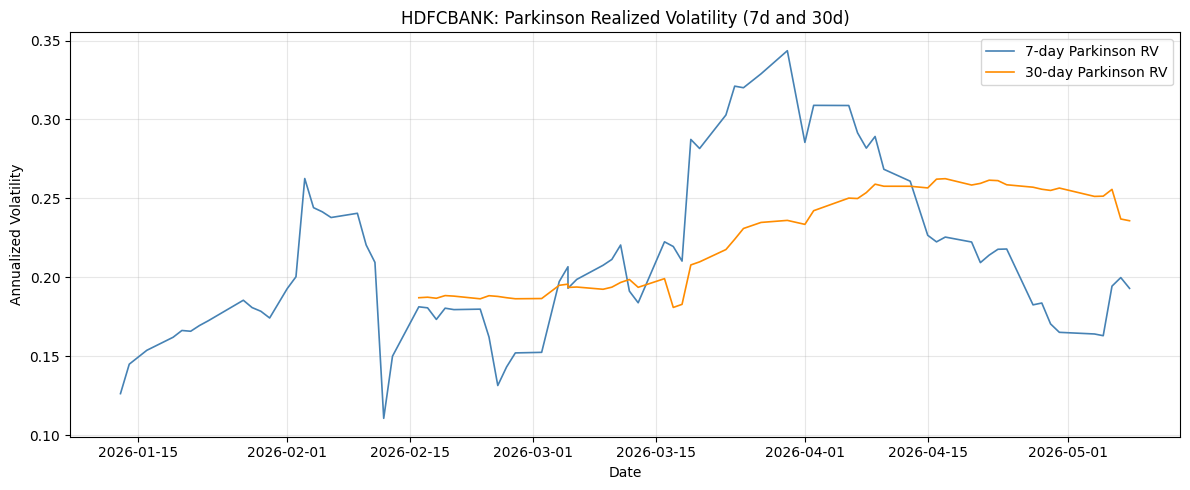

Average 7-day realized vol (annualized): 0.2106 (21.06%)
Average 30-day realized vol (annualized): 0.2233 (22.33%)

Latest values:
               rv_7d    rv_30d
Date                          
2026-05-04  0.164198  0.251306
2026-05-05  0.163107  0.251457
2026-05-06  0.194492  0.255757
2026-05-07  0.199910  0.237006
2026-05-08  0.193078  0.235893


In [2]:
# Parkinson daily variance
park_var_daily = (1.0 / (4.0 * np.log(2.0))) * (np.log(valid["High"] / valid["Low"]) ** 2)

# Realized vol (annualized) using rolling mean daily variance
rv_7d = np.sqrt(252.0 * park_var_daily.rolling(7, min_periods=7).mean()).rename("rv_7d")
rv_30d = np.sqrt(252.0 * park_var_daily.rolling(30, min_periods=30).mean()).rename("rv_30d")

rv = pd.concat([rv_7d, rv_30d], axis=1)

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(rv.index, rv["rv_7d"], label="7-day Parkinson RV", linewidth=1.2, color="steelblue")
ax.plot(rv.index, rv["rv_30d"], label="30-day Parkinson RV", linewidth=1.2, color="darkorange")
ax.set_title("HDFCBANK: Parkinson Realized Volatility (7d and 30d)")
ax.set_xlabel("Date")
ax.set_ylabel("Annualized Volatility")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

# Average realized vol across available history
avg_7d = rv_7d.mean()
avg_30d = rv_30d.mean()

print(f"Average 7-day realized vol (annualized): {avg_7d:.4f} ({avg_7d*100:.2f}%)")
print(f"Average 30-day realized vol (annualized): {avg_30d:.4f} ({avg_30d*100:.2f}%)")

print("\nLatest values:")
print(rv.dropna(how='all').tail())

In [13]:
def parkinson_rv_table(symbols, from_date="01-06-2025", to_date=None):
    """
    Build a dataframe of latest annualized Parkinson realized vols for each symbol.

    Parameters
    ----------
    symbols : list[str]
        NSE symbols, e.g. ["HDFCBANK", "SBIN", "RELIANCE"]
    from_date : str
        dd-mm-yyyy
    to_date : str | None
        dd-mm-yyyy; if None, uses today

    Returns
    -------
    pd.DataFrame with columns:
    SYMBOL, 5d-RV, 7d-RV, 22d-RV, 30d-RV, 60d-RV
    """
    if to_date is None:
        to_date = date.today().strftime("%d-%m-%Y")

    windows = [5, 7, 22, 30, 60]
    rows = []

    for symbol in symbols:
        try:
            df_s = capital_market.price_volume_data(symbol, from_date, to_date)

            # Parse/clean date
            if "Date" in df_s.columns:
                df_s["Date"] = pd.to_datetime(df_s["Date"], format="mixed", dayfirst=True, errors="coerce")
                df_s = df_s.dropna(subset=["Date"]).sort_values("Date").set_index("Date")
            else:
                if not isinstance(df_s.index, pd.DatetimeIndex):
                    df_s.index = pd.to_datetime(df_s.index, format="mixed", dayfirst=True, errors="coerce")
                df_s = df_s.sort_index()

            # nselib price fields are often strings with thousands separators (e.g. "1,223.20")
            high_raw = df_s.get("HighPrice")
            low_raw = df_s.get("LowPrice")
            high = pd.to_numeric(high_raw.astype(str).str.replace(",", "", regex=False), errors="coerce")
            low = pd.to_numeric(low_raw.astype(str).str.replace(",", "", regex=False), errors="coerce")
            hl = pd.DataFrame({"High": high, "Low": low}).dropna()

            if hl.empty:
                raise ValueError("No valid HighPrice/LowPrice rows")

            # Daily Parkinson variance
            park_var_daily = (1.0 / (4.0 * np.log(2.0))) * (np.log(hl["High"] / hl["Low"]) ** 2)

            row = {"SYMBOL": symbol}
            for w in windows:
                rv = np.sqrt(252.0 * park_var_daily.rolling(w, min_periods=w).mean())
                row[f"{w}d-RV"] = round(100*(float(rv.dropna().iloc[-1])), 2) if rv.dropna().size else np.nan

            rows.append(row)

        except Exception as e:
            print(f"[WARN] {symbol}: {e}")
            rows.append(
                {
                    "SYMBOL": symbol,
                    "5d-RV": np.nan,
                    "7d-RV": np.nan,
                    "22d-RV": np.nan,
                    "30d-RV": np.nan,
                    "60d-RV": np.nan,
                }
            )

    out = pd.DataFrame(rows, columns=["SYMBOL", "5d-RV", "7d-RV", "22d-RV", "30d-RV", "60d-RV"])
    return out


# Example:
symbols = ["HDFCBANK", "RELIANCE","TATAMOTORS"]
rv_df = parkinson_rv_table(symbols)
rv_df

,SYMBOL,5d-RV,7d-RV,22d-RV,30d-RV,60d-RV
0,HDFCBANK,19.77,19.31,20.00,23.59,22.33
1,RELIANCE,20.42,23.25,20.16,22.19,21.96
2,TATAMOTORS,22.99,27.75,28.47,28.27,29.31
